<a href="https://colab.research.google.com/github/stephanie465337/Data-Science-Portfolio-C21/blob/main/Projects/Project-5/Wiki_Pass_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Wikipedia NLP Clustering

##Problem Definition

The goal of this project is to use Natural Language Processing (NLP) to identify the ten most similar people based on their biographies. After cleaning and preprocessing the text, TF-IDF is used to convert biographies into numerical features, and K-Nearest Neighbors (KNN) is used to measure similarity between individuals. Sentiment analysis is performed on the reference person’s biography, and similarity rankings from DBpedia summaries are compared with rankings from full Wikipedia articles. Finally, an interactive notebook allows users to select a person and view their ten closest matches.

##Data Collection

In [1]:
%%capture install_output
%%bash

#Install necessary NLP and Wikipedia API libraries
pip install -q -U textblob wikipedia-api
#Download TextBlob for NLP tasks
python -m textblob.download_corpora

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import wikipediaapi
import ipywidgets as widgets #Used to create dropdown and button
import urllib.parse #Used to decode special (foreign) characters

from textblob import TextBlob #Tokenization, Counting words, Parts of Speech Sentiment Analysis
# from textblob import Word #Lemmatization
from sklearn.feature_extraction.text import CountVectorizer #Understand Bag of Words
from sklearn.feature_extraction.text import TfidfVectorizer #Final Representation
from sklearn.neighbors import NearestNeighbors #Primary algorithm
from IPython.display import display #Pushes widgets to screen

In [3]:
#Define URL
url = 'https://ddc-datascience.s3.amazonaws.com/Projects/Project.5-NLP/Data/NLP.csv'
url

'https://ddc-datascience.s3.amazonaws.com/Projects/Project.5-NLP/Data/NLP.csv'

In [4]:
#Read CSV
df = pd.read_csv(url)
df

,URI,name,text
0,<http://dbpedia.org/resource/Digby_Morrell>,Digby Morrell,digby morrell born 10 october 1979 is a former...
1,<http://dbpedia.org/resource/Alfred_J._Lewy>,Alfred J. Lewy,alfred j lewy aka sandy lewy graduated from un...
2,<http://dbpedia.org/resource/Harpdog_Brown>,Harpdog Brown,harpdog brown is a singer and harmonica player...
3,<http://dbpedia.org/resource/Franz_Rottensteiner>,Franz Rottensteiner,franz rottensteiner born in waidmannsfeld lowe...
4,<http://dbpedia.org/resource/G-Enka>,G-Enka,henry krvits born 30 december 1974 in tallinn ...
...,...,...,...
42781,<http://dbpedia.org/resource/Motoaki_Takenouchi>,Motoaki Takenouchi,motoaki takenouchi born july 8 1967 saitama pr...
42782,<http://dbpedia.org/resource/Alan_Judge_(footb...,"Alan Judge (footballer, born 1960)",alan graham judge born 14 may 1960 is a retire...
42783,<http://dbpedia.org/resource/Eduardo_Lara>,Eduardo Lara,eduardo lara lozano born 4 september 1959 in c...
42784,<http://dbpedia.org/resource/Tatiana_Faberg%C3...,Tatiana Faberg%C3%A9,tatiana faberg is an author and faberg scholar...


##Data Cleaning

In [5]:
#Rows and columns
df.shape

(42786, 3)

In [6]:
#Columns, data types and memory usage
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42786 entries, 0 to 42785
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   URI     42786 non-null  object
 1   name    42786 non-null  object
 2   text    42786 non-null  object
dtypes: object(3)
memory usage: 1002.9+ KB


###Missing Values

In [7]:
#Missing values per column
df.isnull().sum()

,0
URI,0
name,0
text,0


###Duplicates

In [8]:
#Across entire df
df.duplicated().sum()

np.int64(0)

In [9]:
#Check URI column
df['URI'].duplicated().sum()

np.int64(0)

In [10]:
#Check name column
df['name'].duplicated().sum()

np.int64(1)

In [11]:
#View rows with duplicate names
df[df['name'].duplicated(keep=False)]

,URI,name,text
787,<http://dbpedia.org/resource/James_Grieve_(tra...,author),james grieve born 1934 is an australian transl...
17249,<http://dbpedia.org/resource/Steve_Greenberg_(...,author),steve greenberg december 20 1960 is an america...


In [12]:
#Extract name from URI (everything between resource/ and the next parenthesis/underscore details)
extracted_names = df['URI'].str.extract(r'resource/([^_(]+)')[0]

#Replace underscores with spaces (ex: 'James_Grieve' -> 'James Grieve')
extracted_names = extracted_names.str.replace('_', ' ').str.strip()

#Update 'clean_name' only for rows where clean_name contains is 'author)'
mask = df['name'].str.contains(r'^author\)$', regex=True, na=False) # ^: Asserts start of str, \: closing ) since () have special meaning in regex, $: Asserts end of str
df.loc[mask, 'name'] = extracted_names[mask]

In [13]:
#Confirm
df[df['name'].str.contains(r'^author\)$', na=False)]

,URI,name,text


In [14]:
#Check text column
df['text'].duplicated().sum()

np.int64(0)

###Column Name

Keep (parentheses) to differenciate between Duplicate names

In [15]:
#Unique names
df['name'].nunique()

42786

In [16]:
#Double check for nulls
df['name'].isnull().sum()

np.int64(0)

In [17]:
#Create clean 'name' column
df['clean_name'] = df['name']

####Extra Spaces

In [18]:
#Remove extra spaces
df['clean_name'] = (
    df['clean_name']
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

####Special Characters

In [19]:
#Decode URL-encoded special characters
df['clean_name'] = df['name'].apply(urllib.parse.unquote)

In [20]:
#Test
df[df['name'].str.contains('Javier S', case=False, na=False)][
    ['name', 'clean_name', 'text']
]

,name,clean_name,text
10133,Javier S%C3%A1nchez,Javier Sánchez,javier snchez vicario born 1968 in pamplona sp...
34536,Javier Santiso,Javier Santiso,javier santiso is a young global leader ygl of...


In [21]:
#Check for rows with '%'
df[df['clean_name'].str.contains('%', na=False)]

,URI,name,text,clean_name


####Duplicates

In [22]:
#Double check after cleaning
df.duplicated().sum()

np.int64(0)

In [23]:
#Double check clean names
df['clean_name'].duplicated().sum()

np.int64(0)

In [24]:
#Double double check
df[df['clean_name'].duplicated(keep=False)]

,URI,name,text,clean_name


###Column Text

In [25]:
#Create clean 'text' column
df["clean_text"] = df["text"]

In [26]:
 #Double check for nulls
df["text"].isnull().sum()

np.int64(0)

In [27]:
#Check if text is filled with whitespace
(df["text"].str.strip() == "").sum()

np.int64(0)

In [28]:
#Calc len of text
df["text_length"] = df["text"].apply(len)

#Display len summary
df["text_length"].describe().transpose()

,text_length
count,42786.000000
mean,1896.548801
std,833.085754
min,1049.000000
25%,1386.000000
50%,1655.000000
75%,2125.000000
max,31850.000000


####Lowercase

In [29]:
#Lowercase
df["clean_text"] = df["clean_text"].str.lower()

####Remove Punctuation

In [30]:
#Remove punctuation
df["clean_text"] = (
    df["clean_text"]
    .str.replace(
        r"[^\w\s]", #Means keep words and spaces, remove everything else
        "",
        regex=True
    )
)


####Extra Spaces

In [31]:
#Remove extra spaces
df["clean_text"] = (
    df["clean_text"]
    .str.replace(
        r"\s+",
        " ",
        regex=True
    )
    .str.strip()
)

####Tokens

In [32]:
#Tokenization (TextBlob)
df["tokens"] = df["clean_text"].apply(
    lambda x: TextBlob(x).words
)

####Remove Stop Words

In [33]:
#Remove stopwords
TfidfVectorizer(stop_words="english")

TfidfVectorizer(stop_words='english')

####Correct Spelling

This will take a long time. Save until ready to save to Hugging Face.

####Lemmatization

In [34]:
#Lemmatization (convert plurals, standardizes verbs, etc.)
df["clean_text"] = df["clean_text"].apply(
    lambda text: " "
    .join([w.lemmatize()
    for w in TextBlob(text)
    .words
]))

In [35]:
#Compare before and after
df[["text", "clean_text"]].head()

,text,clean_text
0,digby morrell born 10 october 1979 is a former...,digby morrell born 10 october 1979 is a former...
1,alfred j lewy aka sandy lewy graduated from un...,alfred j lewy aka sandy lewy graduated from un...
2,harpdog brown is a singer and harmonica player...,harpdog brown is a singer and harmonica player...
3,franz rottensteiner born in waidmannsfeld lowe...,franz rottensteiner born in waidmannsfeld lowe...
4,henry krvits born 30 december 1974 in tallinn ...,henry krvits born 30 december 1974 in tallinn ...


In [43]:
# Change this to any name in your dataset
person_name = "Digby Morrell"

# Extract the biography
bio = df.loc[df['clean_name'] == person_name, 'text'].iloc[0]

# Print the full biography
print(bio)

digby morrell born 10 october 1979 is a former australian rules footballer who played with the kangaroos and carlton in the australian football league aflfrom western australia morrell played his early senior football for west perth his 44game senior career for the falcons spanned 19982000 and he was the clubs leading goalkicker in 2000 at the age of 21 morrell was recruited to the australian football league by the kangaroos football club with its third round selection in the 2001 afl rookie draft as a forward he twice kicked five goals during his time with the kangaroos the first was in a losing cause against sydney in 2002 and the other the following season in a drawn game against brisbaneafter the 2003 season morrell was traded along with david teague to the carlton football club in exchange for corey mckernan he played 32 games for the blues before being delisted at the end of 2005 he continued to play victorian football league vfl football with the northern bullants carltons vflaf

###Clean DataFrame

In [44]:
#Create new DataFrame with clean name and text
df_clean = df[['clean_name', 'clean_text']].copy()
df_clean

,clean_name,clean_text
0,Digby Morrell,digby morrell born 10 october 1979 is a former...
1,Alfred J. Lewy,alfred j lewy aka sandy lewy graduated from un...
2,Harpdog Brown,harpdog brown is a singer and harmonica player...
3,Franz Rottensteiner,franz rottensteiner born in waidmannsfeld lowe...
4,G-Enka,henry krvits born 30 december 1974 in tallinn ...
...,...,...
42781,Motoaki Takenouchi,motoaki takenouchi born july 8 1967 saitama pr...
42782,"Alan Judge (footballer, born 1960)",alan graham judge born 14 may 1960 is a retire...
42783,Eduardo Lara,eduardo lara lozano born 4 september 1959 in c...
42784,Tatiana Fabergé,tatiana faberg is an author and faberg scholar...


#NLP Preprocessing

##Part 1 - Reference Person

1. Pick one person from the list ( the reference person ) and output 10 other people who's overview are "closest" to the reference person in a Natural Language Processing sense
2. Also output the sentiment of the overview of the reference person


In [45]:
#Randomly select a person
df_clean['clean_name'].sample(1)

,clean_name
37071,David Marquardt


In [47]:
#Assign reference person and make sure they can be found
reference_person = 'L. Desaix Anderson'

person = df_clean[df_clean['clean_name'] == reference_person]

if person.empty:
  print('Person not found.')
else:
  reference_text = person['clean_text'].iloc[0]
  #Create blob
  blob = TextBlob(reference_text)
  print(blob.sentences)

[Sentence("l desaix anderson born 1936 is a career united state foreign service officer specializing in east asian affair and served a american charg daffaires ad interim to vietnammr anderson a 35year veteran of the u foreign service spent most of his career working on asian issue he wa the first envoy to the socialist republic of vietnam following establishment of diplomatic relation serving a charg daffaires from august 1995 when the embassy opened until 1997mr anderson wa born in 1936 and wa raised on a farm in rural mississippi he received his ba in history from princeton university and did graduate work in european literature at the university of california at berkeley he also served on active duty a an officer in the u navy from 1958 to 1960 after which he managed his family farm in mississippihe entered the foreign service in 1962 his first assignment wa in kathmandu nepal a general service officer 196364 mr anderson wa assigned to vietnam a an aid provincial representative and

###Bag of Words (CountVectorizer)

In [49]:
#Filter stop words
bow = CountVectorizer(stop_words='english')
#Convert to matrix
bow_matrix = bow.fit_transform(df_clean['clean_text'])

print('Bag of Words shape:', bow_matrix.shape)

Bag of Words shape: (42786, 423641)


###Text Representation (TF-IDF)


**Why TF-IDF?** It gives more importance to meaningful words and less importance to common words like "the", "and", and "of". This makes biographies easier to compare.

In [50]:
tfidf = TfidfVectorizer(stop_words='english')

tfidf_matrix = tfidf.fit_transform(df_clean['clean_text'])

###Similarity Search (KNN)

In [51]:
knn = NearestNeighbors(
    n_neighbors=11,
    metric='cosine'
)

knn.fit(tfidf_matrix)

NearestNeighbors(metric='cosine', n_neighbors=11)

In [52]:
reference_index = df_clean[df_clean['clean_name'] == reference_person].index[0]

In [53]:
distances, indices = knn.kneighbors(tfidf_matrix[reference_index])

In [54]:
results = pd.DataFrame({
    'Name': df_clean.iloc[indices[0][1:]]['clean_name'].values,
    'Distance': distances[0][1:]
})

results

,Name,Distance
0,Eric G. John,0.712100
1,Douglas L. McElhaney,0.733283
2,Bud Anderson (baseball),0.739377
3,Peter Tarnoff,0.742770
4,"Harvey Frans Nelson, Jr.",0.745926
5,David Anderson (British Columbia politician),0.747901
6,Whitney Anderson,0.756561
7,Andrey Tatarinov,0.761150
8,David A. Korn,0.767395
9,Nguyễn Thị Bình,0.769541


In [55]:
blob = TextBlob(reference_text)

In [56]:
sentiment = blob.sentiment

In [57]:
print('Reference Person:', reference_person)
print('Polarity:', sentiment.polarity)

Reference Person: L. Desaix Anderson
Polarity: 0.07852077001013172


In [58]:
if sentiment.polarity > 0:
  label = 'Positive'
elif sentiment.polarity < 0:
  label = 'Negative'
else:
  label = 'Neutral'

print('Sentiment:', label)

Sentiment: Positive


###**What I have accomplished**

- A reference person
- Their biography
- A TF-IDF representation of every biography
- A KNN model that finds similar biographies
- A table of the 10 most similar people
- The sentiment (polarity and subjectivity) of the reference person's overview

##Part 2 - Wikipedia

1. Print out the text of the Wikipedia article for the reference person
2. Determine the sentiment of the text of the Wikipedia page for the reference person
1. Collect the text of the Wikipedia pages from the 10 nearest neighbors from Part 1
1. Determine the nearness ranking of these 10 people to your reference person based on their entire Wikipedia page
1. Compare, i.e. plot, the nearest ranking from Step 1) with the Wikipedia page nearness ranking. A difference of the rank is one means of comparison.

In [59]:
wiki = wikipediaapi.Wikipedia(
    user_agent='NLP_Project/1.0',
    language='en'
)

In [60]:
page = wiki.page(reference_person)

In [61]:
if page.exists():
  print('Page found.')
else:
  print('Page not found.')

Page found.


In [62]:
reference_wiki = page.text

print(reference_wiki[:1000])

Laurence Desaix Anderson (February 12, 1936 – February 11, 2021) was a career United States Foreign Service officer specializing in East Asian affairs, and served as American Chargé d'Affaires ad interim to Vietnam.

Career
Anderson, a 35-year veteran of the U.S. Foreign Service, spent most of his career working on Asian issues. He was the first envoy to the Socialist Republic of Vietnam, following the establishment of diplomatic relations, serving as chargé d'affaires from August 1995 when the embassy opened until 1997.
Anderson was born in 1936 in Sumner, Mississippi. He received his B.A. in history from Princeton University, and did graduate work in European literature at the University of California at Berkeley. He also served on active duty as an officer in the U.S. Navy from 1958 to 1960, after which he managed his family farm in Mississippi.
He entered the Foreign Service in 1962. His first assignment was in Kathmandu, Nepal, as General Services Officer (1963–64). Anderson was t

In [63]:
wiki_blob = TextBlob(reference_wiki)

print('Reference Person:', reference_person)
print('Wikipedia Polarity:', wiki_blob.sentiment.polarity)
print('Wikipedia Subjectivity:', wiki_blob.sentiment.subjectivity)

Reference Person: L. Desaix Anderson
Wikipedia Polarity: 0.08582502768549281
Wikipedia Subjectivity: 0.19138981173864894


In [64]:
#Collect each article
wiki_texts = []

for name in results['Name']:
  page = wiki.page(name)

  if page.exists():
    wiki_texts.append(page.text)
  else:
    wiki_texts.append('')

In [65]:
#Create new DataFrame
wiki_df = results.copy()

wiki_df['Wikipedia_Text'] = wiki_texts

In [66]:
comparison_df = pd.DataFrame({
    'Name': [reference_person] + wiki_df['Name'].tolist(),
    'Text': [reference_wiki] + wiki_df['Wikipedia_Text'].tolist()
})

In [67]:
#TF-IDF on Wikipedia Articles
wiki_tfidf = TfidfVectorizer(stop_words='english')

wiki_matrix = wiki_tfidf.fit_transform(comparison_df['Text'])

In [68]:
#Run KNN Again
wiki_knn = NearestNeighbors(
    n_neighbors=11,
    metric='cosine'
)

wiki_knn.fit(wiki_matrix)

NearestNeighbors(metric='cosine', n_neighbors=11)

In [69]:
#Find neighbors of the reference article
distances, indices = wiki_knn.kneighbors(wiki_matrix[0]) #0 is the reference person

In [70]:
#Create the Wikipedia Ranking
wiki_results = pd.DataFrame({
    'Wikipedia Rank': range(1,11),
    'Name': comparison_df.iloc[indices[0][1:]]['Name'].values
})

wiki_results

,Wikipedia Rank,Name
0,1,David Anderson (British Columbia politician)
1,2,Peter Tarnoff
2,3,Eric G. John
3,4,Douglas L. McElhaney
4,5,Whitney Anderson
5,6,"Harvey Frans Nelson, Jr."
6,7,Bud Anderson (baseball)
7,8,Nguyễn Thị Bình
8,9,Andrey Tatarinov
9,10,David A. Korn


In [71]:
#Merge and Compare Rankings
part1_ranks = results[['Name']].copy()
part1_ranks['DBpedia Rank'] = range(1, len(part1_ranks) + 1)

part2_ranks = wiki_results.copy()

comparison = part1_ranks.merge(part2_ranks, on='Name')

comparison

,Name,DBpedia Rank,Wikipedia Rank
0,Eric G. John,1,3
1,Douglas L. McElhaney,2,4
2,Bud Anderson (baseball),3,7
3,Peter Tarnoff,4,2
4,"Harvey Frans Nelson, Jr.",5,6
5,David Anderson (British Columbia politician),6,1
6,Whitney Anderson,7,5
7,Andrey Tatarinov,8,9
8,David A. Korn,9,10
9,Nguyễn Thị Bình,10,8


In [72]:
#Calculate Rank Difference
comparison['Rank Difference'] = (
    comparison['Wikipedia Rank'] -
    comparison['DBpedia Rank']
).abs()

comparison

,Name,DBpedia Rank,Wikipedia Rank,Rank Difference
0,Eric G. John,1,3,2
1,Douglas L. McElhaney,2,4,2
2,Bud Anderson (baseball),3,7,4
3,Peter Tarnoff,4,2,2
4,"Harvey Frans Nelson, Jr.",5,6,1
5,David Anderson (British Columbia politician),6,1,5
6,Whitney Anderson,7,5,2
7,Andrey Tatarinov,8,9,1
8,David A. Korn,9,10,1
9,Nguyễn Thị Bình,10,8,2


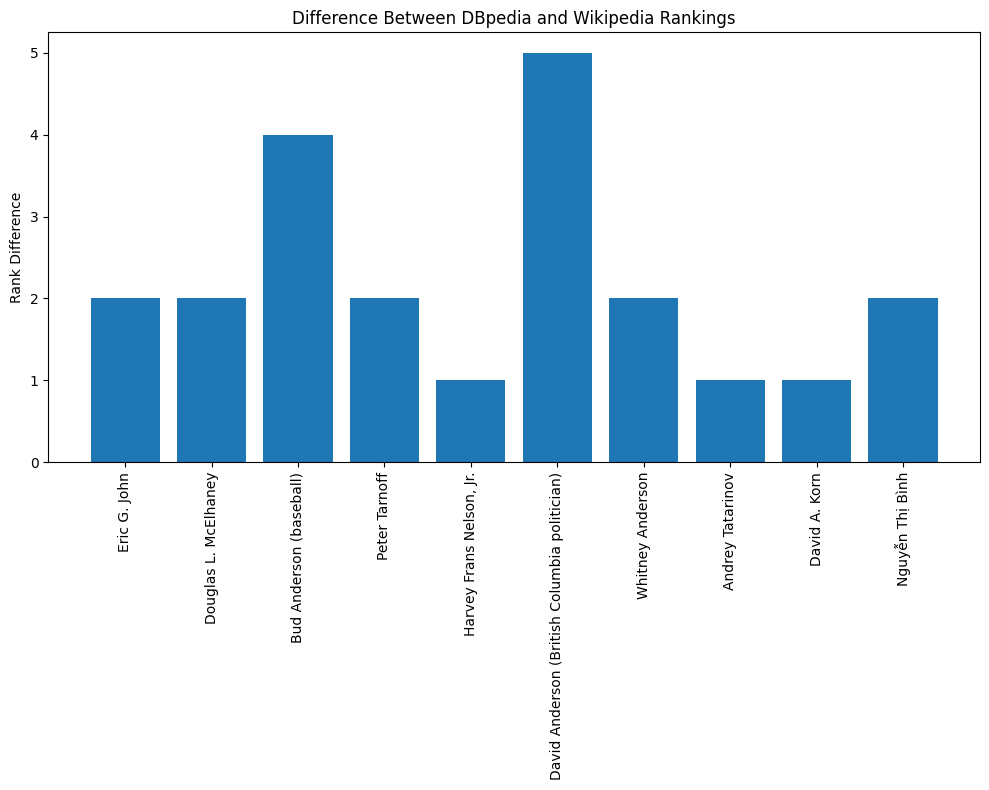

In [73]:
#Plot the Comparison
plt.figure(figsize=(10,8))

plt.bar(
    comparison['Name'],
    comparison['Rank Difference']
)

plt.xticks(rotation=90)
plt.ylabel('Rank Difference')
plt.title('Difference Between DBpedia and Wikipedia Rankings')

plt.tight_layout()
plt.show()

###**How to explain: **

1. **DBpedia Overview** → Short biographies.
2. **Wikipedia Articles** → Full biographies with much more context.
3. **Question:** Does more information change who is considered "most similar"?
4. **Answer:** Compare the rankings and discuss the differences.

##Part 3 - Interactive Notebook

Make an interactive notebook where a user can choose or enter a name and the notebook displays the 10 closest individuals.

In addition to presenting the project slides, at the end of the presentation each student will demonstrate their code using a famous person suggested by the other students that exists in the DBpedia set.

In [74]:
!curl -s https://ddc-datascience.s3.amazonaws.com/Projects/Project.5-NLP/Data/NLP.csv | wc -l

42786


In [75]:
%%bash
curl -s https://ddc-datascience.s3.amazonaws.com/Projects/Project.5-NLP/Data/NLP.csv |
head -1 |
tr , '\n' |
cat -n

     1	URI
     2	name
     3	text


In [76]:
%%bash
curl -s https://ddc-datascience.s3.amazonaws.com/Projects/Project.5-NLP/Data/NLP.csv |
head -2 |
tail -1 |
tr , '\n' |
cat -n

     1	<http://dbpedia.org/resource/Digby_Morrell>
     2	Digby Morrell
     3	digby morrell born 10 october 1979 is a former australian rules footballer who played with the kangaroos and carlton in the australian football league aflfrom western australia morrell played his early senior football for west perth his 44game senior career for the falcons spanned 19982000 and he was the clubs leading goalkicker in 2000 at the age of 21 morrell was recruited to the australian football league by the kangaroos football club with its third round selection in the 2001 afl rookie draft as a forward he twice kicked five goals during his time with the kangaroos the first was in a losing cause against sydney in 2002 and the other the following season in a drawn game against brisbaneafter the 2003 season morrell was traded along with david teague to the carlton football club in exchange for corey mckernan he played 32 games for the blues before being delisted at the end of 2005 he continued to play v

In [77]:
#Create a function
def find_similar_people(person_name):

  #Check if the person exists
  if person_name not in df_clean['clean_name'].values:
    print(f"'{person_name}' was not found in the dataset.")
    return

  #Find the reference person's index
  reference_index = df_clean[df_clean['clean_name'] == person_name].index[0]

  #Find the 10 nearest neighbors
  distances, indices = knn.kneighbors(tfidf_matrix[reference_index])

  #Get the reference person's bigraphy
  reference_text = df_clean.loc[df_clean['clean_name'] == person_name, 'clean_text'].iloc[0]

  #Sentiment Analysis
  blob = TextBlob(reference_text)

  #Create results DataFrame
  results = pd.DataFrame({
      'Name': df_clean.iloc[indices[0][1:]]['clean_name'].values,
      'Distance': distances[0][1:]
  })

  #Display results
  print('=' * 60)
  print(f"Reference Person: {person_name}")
  print('=' * 60)
  print(f'Polarity: {blob.sentiment.polarity:.3f}')
  print(f'Subjectivity: {blob.sentiment.subjectivity:.3f}')
  print()
  print('10 Closest Individuals')
  display(results)

#Create dropdown list
dropdown = widgets.Dropdown(
    options=sorted(df_clean['clean_name'].unique()),
    description='Person:',
    layout=widgets.Layout(width='450px')
)

#Create button
button = widgets.Button(
    description='Find Similar People',
    button_style='success'
)

#Button action
def on_button_clicked(b):
  find_similar_people(dropdown.value)

button.on_click(on_button_clicked)

#Display widgets
display(dropdown)
display(button)

Dropdown(description='Person:', layout=Layout(width='450px'), options=(' Renate Lorenz', "'Ilima Lei Tohi", '1…

Button(button_style='success', description='Find Similar People', style=ButtonStyle())

#THINGS TO CONSIDER

This is an unsupervised clustering problem.


Data Cleaning
- pluras
- special characters
- numbers


Should I try a:
- k-means
- dbscan
- something else

Part 1:
- What kind of distance did you use?
- Why did you opt for that instead of Euclidean?

Part 2: How do you automate it?
- What if I started scaling it? Start with 20 and scale up.
- n-grams n^1, n^2, n^3...